# DataCo Supply Chain Analytics and Predictive ML

**Objective:** Build an end-to-end, business-focused supply chain analytics and machine learning workflow from raw data to production-ready delivery-risk prediction.

**Data Source:** Publicly available DataCo Supply Chain Dataset / Kaggle baseline.

**Project Contribution:** Extend the public dataset into a production-oriented workflow with privacy-aware data preparation, leakage-controlled predictive modeling, business ROI analysis, and deployment-ready artifacts.

**Modeling Boundary:** Historical delivery outcomes may be analyzed retrospectively, but predictive features are restricted to information available at order placement.

In [1]:
# Imports and Configuration - Load only the libraries required for analysis, visualization, modeling, evaluation, and artifact management
# Reasoning - Keep the environment focused and reproducible across the full analytics-to-ML workflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    confusion_matrix
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid")

RAW_FILE = "Raw_DataCoSupplyChainDataset.csv"
CLEAN_FILE = "DataCoSupplyChainDataset.csv"

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load Raw Dataset - Start the project from the original public dataset rather than a previously cleaned copy
# Reasoning - Preserve a transparent audit trail from raw source to final analytical dataset

df = pd.read_csv(RAW_FILE, encoding="latin1")

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,"95,125.00",2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,"90,027.00",2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
# Data Quality Audit - Assess structure, missingness, duplicates, and cardinality before making cleaning decisions
# Reasoning - Base every cleaning decision on observed data quality rather than assumptions

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique()
})

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

display(audit.sort_values("missing", ascending=False).head(15))

Rows: 180,519
Columns: 53
Duplicate rows: 0


,dtype,missing,missing_%,unique
Product Description,float64,180519,100.00,0
Order Zipcode,float64,155679,86.24,609
Customer Lname,object,8,0.00,1109
Customer Zipcode,float64,3,0.00,995
Type,object,0,0.00,4
Order Profit Per Order,float64,0,0.00,21998
Order Item Cardprod Id,int64,0,0.00,118
Order Item Discount,float64,0,0.00,1017
Order Item Discount Rate,float64,0,0.00,18
Order Item Id,int64,0,0.00,180519


In [4]:
# Data Cleaning and Privacy - Remove unusable fields and personal information not required for business analysis
# Reasoning - Reduce noise, avoid unnecessary exposure of personal data, and retain only analytically relevant information

drop_cols = [
    "Product Description",
    "Order Zipcode",
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"Removed columns: {len([c for c in drop_cols if c in df.columns])}")
print(f"Remaining shape: {df.shape}")

Removed columns: 0
Remaining shape: (180519, 46)


In [5]:
# Date Preparation and Validation - Convert operational dates to datetime and confirm the cleaned dataset is structurally valid
# Reasoning - Reliable dates are required for time-based analysis and prevent invalid records from entering downstream workflows

date_cols = ["order date (DateOrders)", "shipping date (DateOrders)"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

missing_dates = df[date_cols].isna().sum().sum()

print("Date columns converted successfully.")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Date conversion errors: {missing_dates:,}")

assert df.duplicated().sum() == 0
assert missing_dates == 0

print("Data validation passed.")

Date columns converted successfully.
Missing values: 3
Duplicate rows: 0
Date conversion errors: 0
Data validation passed.


## Leakage and Analysis Boundary

Historical delivery information can be used to understand past operational performance, but predictive modeling must respect the information available at the moment an order is placed.

'Days for shipping (real)' represents actual shipping duration and is therefore suitable for retrospective operational analysis but not for order-time prediction.

'Days for shipment (scheduled)' represents the scheduled shipping duration and can be evaluated as a prediction-time candidate.

Post-shipment fields and the target itself are excluded from the ML feature set so the model does not learn from information that would only become available after the outcome occurs.

In [6]:
# Save Clean Dataset - Create a reproducible handoff between data preparation, business analysis, and predictive modeling
# Reasoning - Preserve one validated dataset as the common source for the remaining workflow

df.to_csv(CLEAN_FILE, index=False)

print(f"Clean dataset saved: {df.shape}")

Clean dataset saved: (180519, 46)


In [7]:
# Executive KPI Snapshot - Establish the core business baseline before investigating individual drivers
# Reasoning - Give management a concise view of scale, profitability, and delivery performance

sales = df["Sales"].sum()
profit = df["Order Profit Per Order"].sum()

kpis = pd.Series({
    "Order Items": len(df),
    "Sales": sales,
    "Profit": profit,
    "Profit Margin (%)": profit / sales * 100,
    "Late Delivery Rate (%)": df["Late_delivery_risk"].mean() * 100,
    "Average Actual Shipping Days": df["Days for shipping (real)"].mean()
})

display(kpis.round(2))

Order Items                       180,519.00
Sales                          36,784,735.01
Profit                          3,966,902.97
Profit Margin (%)                      10.78
Late Delivery Rate (%)                 54.83
Average Actual Shipping Days            3.50
dtype: float64

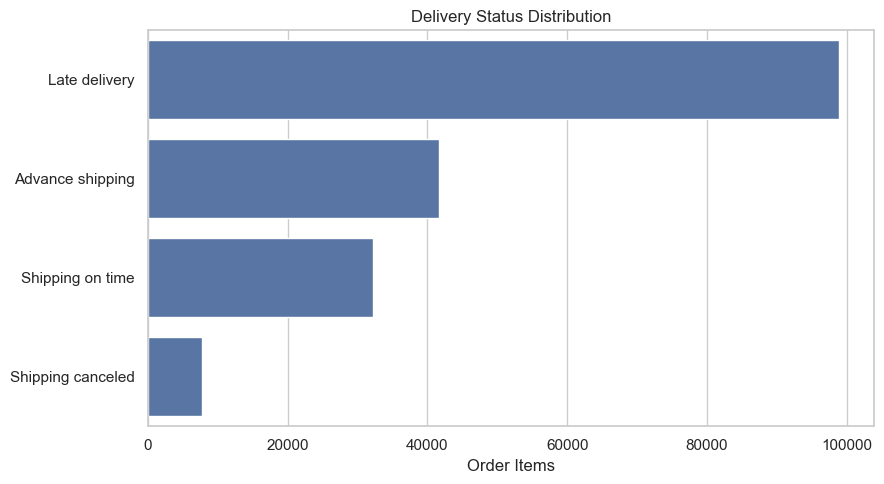

In [8]:
# Delivery Status Distribution - Assess the overall delivery outcome mix before investigating operational drivers
# Reasoning - Establish the scale of each delivery outcome and identify whether late delivery is a material business issue

delivery = df["Delivery Status"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=delivery.values, y=delivery.index)
plt.title("Delivery Status Distribution")
plt.xlabel("Order Items")
plt.ylabel("")
plt.tight_layout()
plt.show()

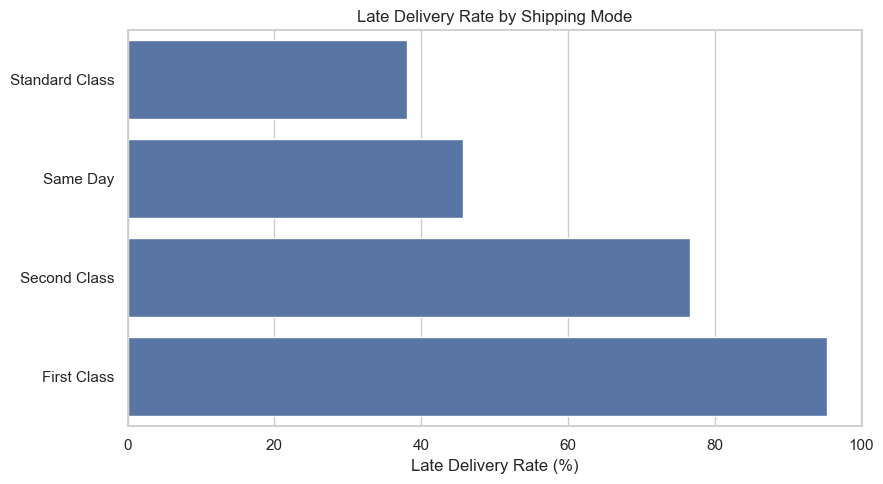

Shipping Mode
Standard Class   38.07
Same Day         45.74
Second Class     76.63
First Class      95.32
Name: Late_delivery_risk, dtype: float64

In [9]:
# Late Delivery Rate by Shipping Mode - Compare delivery risk across shipping modes using rates rather than order volumes
# Reasoning - Normalize for shipment volume so higher-risk modes are identified independently of how frequently each mode is used

shipping_risk = (
    df.groupby("Shipping Mode")["Late_delivery_risk"]
      .mean()
      .mul(100)
      .sort_values()
)

plt.figure(figsize=(9, 5))
sns.barplot(x=shipping_risk.values, y=shipping_risk.index)
plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(shipping_risk.round(2))

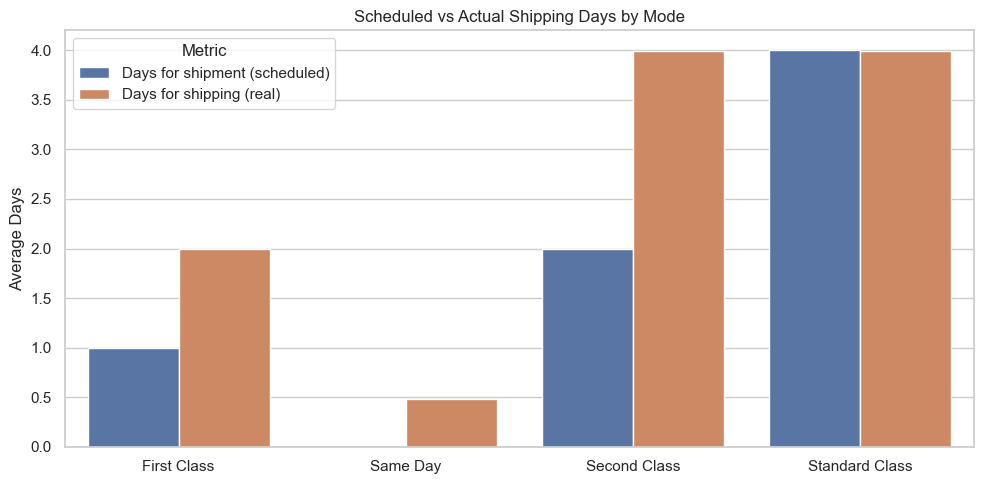

In [10]:
# Scheduled vs Actual Shipping Days - Compare planned and actual shipping timelines by shipping mode
# Reasoning - Identify execution gaps between operational commitments and observed shipping duration

shipping_days = (
    df.groupby("Shipping Mode")[["Days for shipment (scheduled)", "Days for shipping (real)"]]
      .mean()
      .reset_index()
      .melt(id_vars="Shipping Mode", var_name="Metric", value_name="Days")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=shipping_days, x="Shipping Mode", y="Days", hue="Metric")
plt.title("Scheduled vs Actual Shipping Days by Mode")
plt.xlabel("")
plt.ylabel("Average Days")
plt.tight_layout()
plt.show()

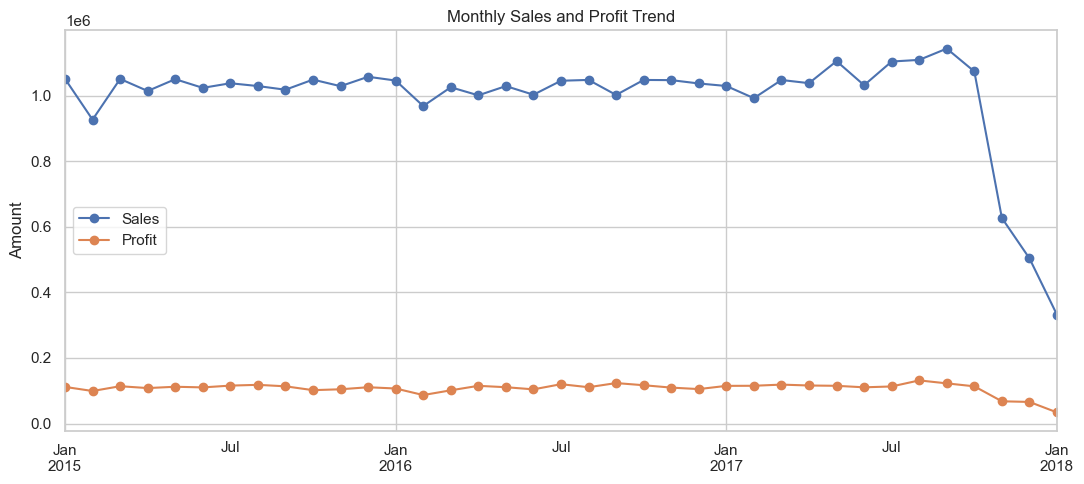

In [11]:
# Monthly Sales and Profit Trend - Track commercial performance across the business timeline
# Reasoning - Detect sustained changes or periods that may warrant deeper commercial or operational investigation

monthly = (
    df.assign(Month=df["order date (DateOrders)"].dt.to_period("M").dt.to_timestamp())
      .groupby("Month")[["Sales", "Order Profit Per Order"]]
      .sum()
)

fig, ax = plt.subplots(figsize=(11, 5))
monthly["Sales"].plot(ax=ax, marker="o", label="Sales")
monthly["Order Profit Per Order"].plot(ax=ax, marker="o", label="Profit")
ax.set_title("Monthly Sales and Profit Trend")
ax.set_xlabel("")
ax.set_ylabel("Amount")
ax.legend()
plt.tight_layout()
plt.show()

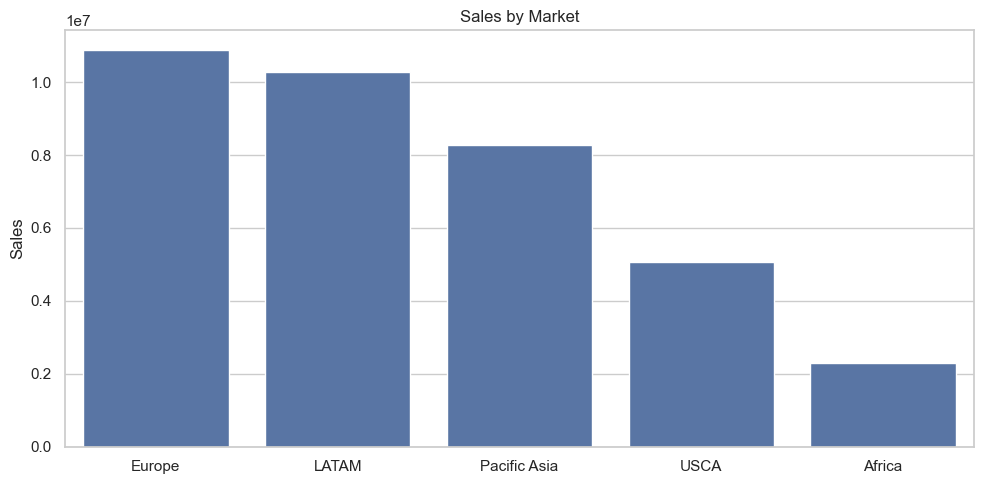

,Sales,Profit,Margin
Market,,,
Europe,"10,872,396.80","1,169,442.96",10.76
LATAM,"10,277,612.84","1,123,321.61",10.93
Pacific Asia,"8,273,743.74","857,753.44",10.37
USCA,"5,066,528.71","564,313.78",11.14
Africa,"2,294,452.93","252,071.18",10.99


In [12]:
# Market Performance - Compare sales and profitability across major markets
# Reasoning - Identify where revenue is concentrated and whether high-sales markets also generate strong profit

market = (
    df.groupby("Market")
      .agg(Sales=("Sales", "sum"), Profit=("Order Profit Per Order", "sum"))
)
market["Margin"] = market["Profit"] / market["Sales"] * 100
market = market.sort_values("Sales", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=market.reset_index(), x="Market", y="Sales")
plt.title("Sales by Market")
plt.xlabel("")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

display(market.round(2))

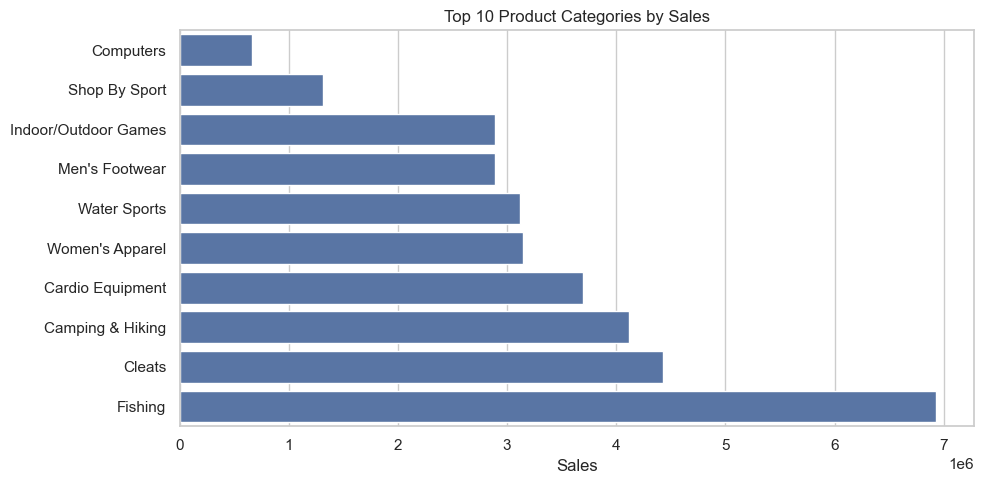

In [13]:
# Top Product Categories - Identify the highest-value product categories by sales
# Reasoning - Focus commercial attention on the categories contributing most to revenue rather than treating all categories equally

category_sales = (
    df.groupby("Category Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 5))
sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Sales")
plt.ylabel("")
plt.tight_layout()
plt.show()

,Sales,Profit,Late_Delivery_Rate
Customer Segment,,,
Consumer,"19,095,790.16","2,073,487.67",54.81
Corporate,"11,168,406.84","1,202,574.96",54.72
Home Office,"6,520,538.02","690,840.34",55.07


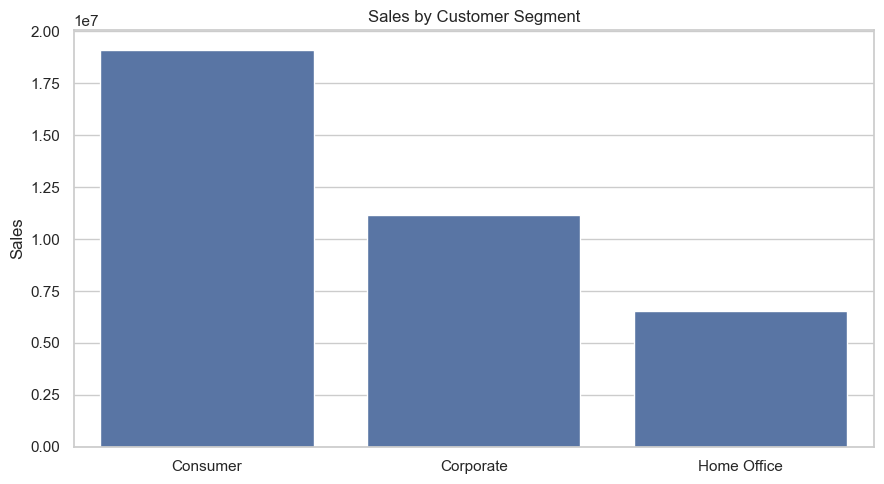

In [14]:
# Customer Segment Performance - Compare sales, profit, and delivery risk across customer segments
# Reasoning - Identify where business value is concentrated and whether major customer groups face different delivery exposure

segment = (
    df.groupby("Customer Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Order Profit Per Order", "sum"),
          Late_Delivery_Rate=("Late_delivery_risk", "mean")
      )
)

segment["Late_Delivery_Rate"] *= 100
segment = segment.sort_values("Sales", ascending=False)

display(segment.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(data=segment.reset_index(), x="Customer Segment", y="Sales")
plt.title("Sales by Customer Segment")
plt.xlabel("")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

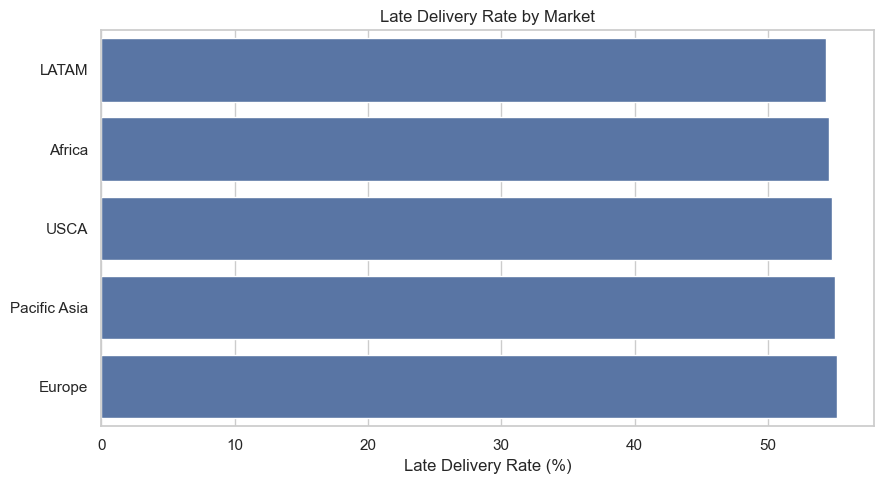

Market
LATAM          54.36
Africa         54.59
USCA           54.80
Pacific Asia   55.05
Europe         55.21
Name: Late_delivery_risk, dtype: float64

In [15]:
# Late Delivery Risk by Market - Compare delivery risk across major markets
# Reasoning - Test whether geography materially differentiates delivery risk before prioritizing operational drivers

market_risk = (
    df.groupby("Market")["Late_delivery_risk"]
      .mean()
      .mul(100)
      .sort_values()
)

plt.figure(figsize=(9, 5))
sns.barplot(x=market_risk.values, y=market_risk.index)
plt.title("Late Delivery Rate by Market")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(market_risk.round(2))

,Shipping Mode,Days for shipment (scheduled),Late_Delivery_Rate,Actual_Shipping_Days
0,First Class,1,95.32,2.00
1,Same Day,0,45.74,0.48
2,Second Class,2,76.63,3.99
3,Standard Class,4,38.07,4.00


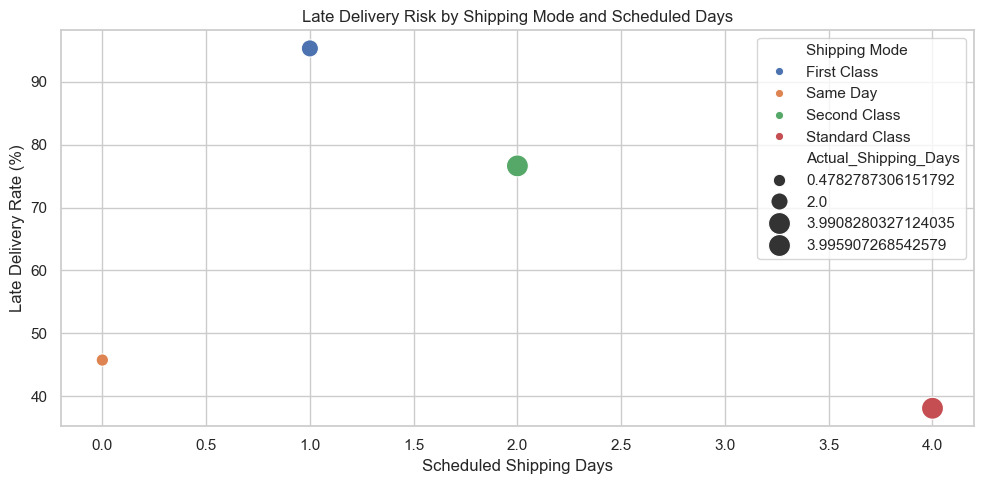

In [16]:
# Late Delivery Risk Drivers - Examine delivery risk across shipping modes and scheduled shipping time
# Reasoning - Connect operational planning variables with observed late-delivery outcomes before predictive modeling

risk_driver = (
    df.groupby(["Shipping Mode", "Days for shipment (scheduled)"])
      .agg(
          Late_Delivery_Rate=("Late_delivery_risk", "mean"),
          Actual_Shipping_Days=("Days for shipping (real)", "mean")
      )
      .reset_index()
)

risk_driver["Late_Delivery_Rate"] *= 100
display(risk_driver.round(2))

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=risk_driver,
    x="Days for shipment (scheduled)",
    y="Late_Delivery_Rate",
    hue="Shipping Mode",
    size="Actual_Shipping_Days",
    sizes=(80, 250)
)
plt.title("Late Delivery Risk by Shipping Mode and Scheduled Days")
plt.xlabel("Scheduled Shipping Days")
plt.ylabel("Late Delivery Rate (%)")
plt.tight_layout()
plt.show()

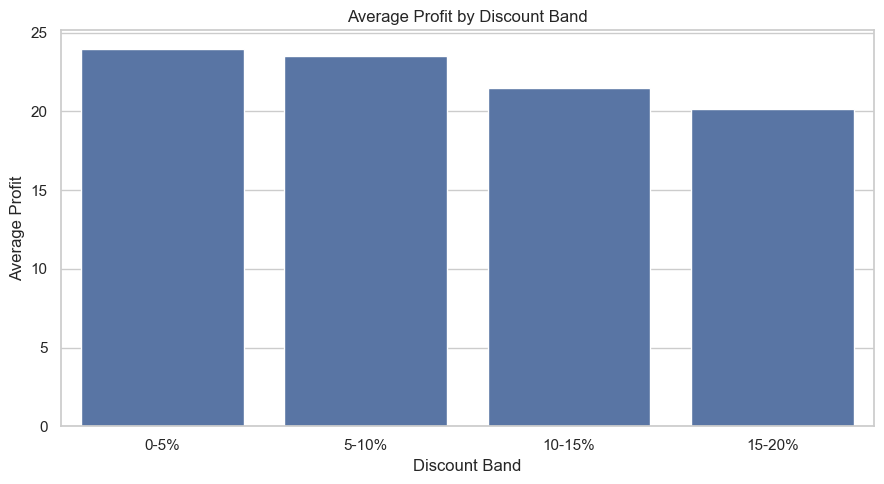

Discount Band
0-5%     23.94
5-10%    23.51
10-15%   21.47
15-20%   20.14
Name: Order Profit Per Order, dtype: float64

In [17]:
# Profitability by Discount Level - Compare average profit across discount bands
# Reasoning - Quantify whether higher discount levels are associated with weaker profitability and potential margin pressure

df["Discount Band"] = pd.cut(
    df["Order Item Discount Rate"],
    bins=[-0.01, 0.05, 0.10, 0.15, 0.20],
    labels=["0-5%", "5-10%", "10-15%", "15-20%"]
)

discount_profit = (
    df.groupby("Discount Band", observed=False)["Order Profit Per Order"]
      .mean()
)

plt.figure(figsize=(9, 5))
sns.barplot(x=discount_profit.index, y=discount_profit.values)
plt.title("Average Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.show()

display(discount_profit.round(2))

In [18]:
# Executive Findings - Consolidate the most important business signals from the completed analysis
# Reasoning - Keep the final business summary dynamic so conclusions remain aligned with the data if the notebook is rerun

findings = pd.Series({
    "Sales": sales,
    "Profit": profit,
    "Profit Margin (%)": profit / sales * 100,
    "Late Delivery Rate (%)": df["Late_delivery_risk"].mean() * 100,
    "Highest Sales Market": market["Sales"].idxmax(),
    "Highest Sales Category": category_sales.idxmax(),
    "Largest Customer Segment": segment["Sales"].idxmax(),
    "Highest Profit Discount Band": discount_profit.idxmax(),
    "Lowest Profit Discount Band": discount_profit.idxmin()
})

display(findings)

# Business Recommendations - Translate measured signals into practical management actions
# Reasoning - Link findings to decisions while avoiding unsupported causal claims

recommendations = [
    f"Prioritize delivery improvement because the overall late delivery rate is {findings['Late Delivery Rate (%)']:.2f}%.",
    "Review shipping-mode execution because delivery risk varies substantially by shipping mode.",
    f"Focus commercial attention on {findings['Highest Sales Market']} as the highest-sales market.",
    f"Protect the performance of {findings['Highest Sales Category']} as the leading sales category.",
    f"Review discount strategy because average profit declines from the {findings['Highest Profit Discount Band']} band to the {findings['Lowest Profit Discount Band']} band."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

Sales                          36,784,735.01
Profit                          3,966,902.97
Profit Margin (%)                      10.78
Late Delivery Rate (%)                 54.83
Highest Sales Market                  Europe
Highest Sales Category               Fishing
Largest Customer Segment            Consumer
Highest Profit Discount Band            0-5%
Lowest Profit Discount Band           15-20%
dtype: object

1. Prioritize delivery improvement because the overall late delivery rate is 54.83%.
2. Review shipping-mode execution because delivery risk varies substantially by shipping mode.
3. Focus commercial attention on Europe as the highest-sales market.
4. Protect the performance of Fishing as the leading sales category.
5. Review discount strategy because average profit declines from the 0-5% band to the 15-20% band.


In [19]:
# ML Target and Feature Boundary - Define the prediction target and restrict features to order-time information
# Reasoning - Prevent target leakage by separating the historical outcome from variables that would only be known after shipment

df["Target_Late"] = (df["Delivery Status"] == "Late delivery").astype(int)

feature_cols = [
    "Type",
    "Days for shipment (scheduled)",
    "Shipping Mode",
    "Order Item Quantity",
    "Sales",
    "Order Item Discount",
    "Category Name",
    "Department Name",
    "Order Region"
]

X = df[feature_cols].copy()
y = df["Target_Late"]

print(f"Features selected: {len(feature_cols)}")
print(f"Target rate: {y.mean() * 100:.2f}%")
print("Post-shipment delivery fields excluded from the predictive feature set.")

Features selected: 9
Target rate: 54.83%
Post-shipment delivery fields excluded from the predictive feature set.


In [20]:
# Train/Test Split - Separate unseen data before fitting any preprocessing or model
# Reasoning - Preserve an unbiased evaluation set and prevent test-set information from influencing transformations

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_cols)
    ],
    remainder="passthrough"
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {len(numeric_cols)}")

Training shape: (144415, 9)
Testing shape: (36104, 9)
Categorical features: 5
Numeric features: 4


In [21]:
# Baseline Model - Establish a simple reference point before evaluating predictive models
# Reasoning - A useful model should outperform a naive strategy rather than being judged in isolation

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="prior"))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(f"Baseline Accuracy: {accuracy_score(y_test, baseline_pred):.4f}")

Baseline Accuracy: 0.5483


Random Forest Performance


Accuracy    0.70
Precision   0.83
Recall      0.56
F1          0.67
dtype: float64

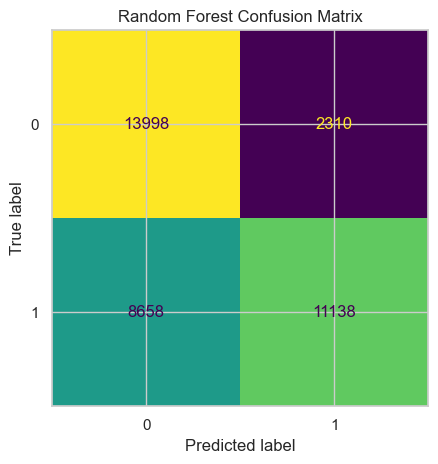

In [22]:
# Random Forest Model - Train a nonlinear ensemble as a robust benchmark for delivery-risk prediction
# Reasoning - Random Forest can capture interactions across operational and commercial features while remaining interpretable through feature importance.

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred)
}

print("Random Forest Performance")
display(pd.Series(rf_metrics).round(4))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, colorbar=False)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

Gradient Boosting Performance


Accuracy    0.70
Precision   0.84
Recall      0.55
F1          0.67
ROC-AUC     0.74
dtype: float64

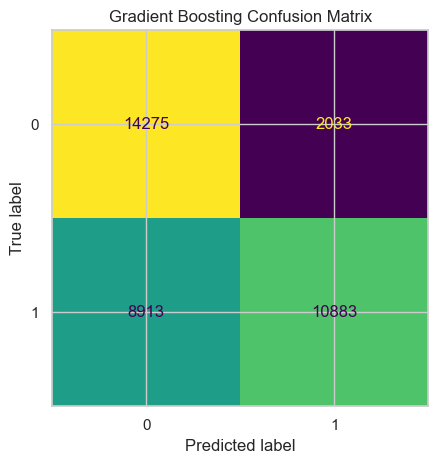

Gradient Boosting 5-Fold CV Accuracy: 0.6947 ± 0.0007
              precision    recall  f1-score   support

           0       0.62      0.88      0.72     16308
           1       0.84      0.55      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.69     36104
weighted avg       0.74      0.70      0.69     36104



In [23]:
# Gradient Boosting Model - Train the candidate production classifier and evaluate probability-based discrimination
# Reasoning - Gradient Boosting can model nonlinear relationships while providing probability estimates required for risk ranking and ROC-AUC

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)
gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]

gb_metrics = {
    "Accuracy": accuracy_score(y_test, gb_pred),
    "Precision": precision_score(y_test, gb_pred),
    "Recall": recall_score(y_test, gb_pred),
    "F1": f1_score(y_test, gb_pred),
    "ROC-AUC": roc_auc_score(y_test, gb_prob)
}

print("Gradient Boosting Performance")
display(pd.Series(gb_metrics).round(4))

ConfusionMatrixDisplay.from_predictions(y_test, gb_pred, colorbar=False)
plt.title("Gradient Boosting Confusion Matrix")
plt.tight_layout()
plt.show()

# Model Validation - Check cross-validation performance for the selected production candidate
# Reasoning - Confirm that holdout performance is not dependent on a single train/test split

cv_scores = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(f"Gradient Boosting 5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(classification_report(y_test, gb_pred))

In [24]:
# Model Comparison - Compare the candidate models using the same holdout set
# Reasoning - Select the production candidate from evidence rather than assuming the more complex model is automatically better

comparison = pd.DataFrame({
    "Baseline": [accuracy_score(y_test, baseline_pred), np.nan, np.nan, np.nan, np.nan],
    "Random Forest": [
        rf_metrics["Accuracy"], rf_metrics["Precision"], rf_metrics["Recall"],
        rf_metrics["F1"], np.nan
    ],
    "Gradient Boosting": [
        gb_metrics["Accuracy"], gb_metrics["Precision"], gb_metrics["Recall"],
        gb_metrics["F1"], gb_metrics["ROC-AUC"]
    ]
}, index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])

display(comparison.round(4))

,Baseline,Random Forest,Gradient Boosting
Accuracy,0.55,0.70,0.70
Precision,NaN,0.83,0.84
Recall,NaN,0.56,0.55
F1,NaN,0.67,0.67
ROC-AUC,NaN,NaN,0.74


,Feature,Importance
1,Days for shipment (scheduled),0.48
5,Order Item Discount,0.47
0,Type,0.04
4,Sales,0.00
8,Order Region,0.00
7,Department Name,0.00
2,Shipping Mode,0.00
3,Order Item Quantity,0.00
6,Category Name,0.00


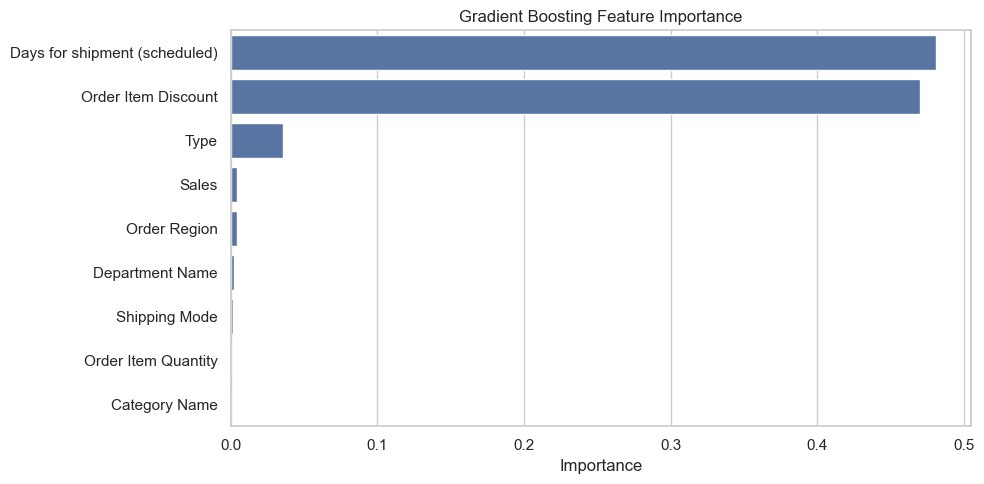

In [25]:
# Feature Importance - Explain which input variables contribute most to the Gradient Boosting model
# Reasoning - Translate model behavior into operational signals that can be discussed with business stakeholders

gb_model = gb_pipeline.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [26]:
# Financial Impact Scenario - Estimate potential business value from the model under explicit assumptions
# Reasoning - Translate predictive performance into a decision-useful scenario without presenting assumed savings as realized results

tn, fp, fn, tp = confusion_matrix(y_test, gb_pred).ravel()

COST_PER_LATE_DELIVERY = 20
EXPEDITE_COST = 5

late_orders = tp + fn
loss_without_ml = late_orders * COST_PER_LATE_DELIVERY
cost_with_ml = (tp + fp) * EXPEDITE_COST + fn * COST_PER_LATE_DELIVERY

net_savings = loss_without_ml - cost_with_ml
roi = net_savings / loss_without_ml * 100 if loss_without_ml else 0
saving_per_order = net_savings / len(y_test)

business_summary = pd.Series({
    "Test Orders": len(y_test),
    "Late Orders": late_orders,
    "Loss Without ML": loss_without_ml,
    "Scenario Cost With ML": cost_with_ml,
    "Estimated Net Savings": net_savings,
    "Estimated ROI (%)": roi,
    "Estimated Savings per Test Order": saving_per_order
})

display(business_summary.round(2))

print("Scenario assumptions:")
print(f"- Late delivery cost: ${COST_PER_LATE_DELIVERY}")
print(f"- Expedite cost: ${EXPEDITE_COST}")
print("These figures represent an assumption-based scenario, not realized financial savings.")

Test Orders                         36,104.00
Late Orders                         19,796.00
Loss Without ML                    395,920.00
Scenario Cost With ML              242,840.00
Estimated Net Savings              153,080.00
Estimated ROI (%)                       38.66
Estimated Savings per Test Order         4.24
dtype: float64

Scenario assumptions:
- Late delivery cost: $20
- Expedite cost: $5
These figures represent an assumption-based scenario, not realized financial savings.


In [27]:
# Production Artifact Handoff - Save the complete preprocessing and model pipeline for deployment
# Reasoning - Package preprocessing with the model so Streamlit applies exactly the same transformations used during training

joblib.dump(gb_pipeline, "supply_chain_model.pkl")
joblib.dump(feature_cols, "model_features.pkl")

metrics = {
    "accuracy": float(gb_metrics["Accuracy"]),
    "precision": float(gb_metrics["Precision"]),
    "recall": float(gb_metrics["Recall"]),
    "f1_score": float(gb_metrics["F1"]),
    "roc_auc": float(gb_metrics["ROC-AUC"]),
    "cross_validation_accuracy": float(cv_scores.mean())
}

with open("model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

business_config = {
    "late_delivery_penalty": COST_PER_LATE_DELIVERY,
    "expedite_cost": EXPEDITE_COST
}

with open("business_config.json", "w") as f:
    json.dump(business_config, f, indent=4)

print("Production artifacts saved successfully.")
print("supply_chain_model.pkl")
print("model_features.pkl")
print("model_metrics.json")
print("business_config.json")

Production artifacts saved successfully.
supply_chain_model.pkl
model_features.pkl
model_metrics.json
business_config.json


In [28]:
# Final Project Handoff - Confirm the dataset, model artifacts, and prediction boundary before deployment
# Reasoning - Provide one final reproducibility checkpoint from raw data through the production model

print(f"Final dataset shape: {df.shape}")
print(f"Clean dataset columns: {df.shape[1]}")
print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")
print(f"Selected model: Gradient Boosting")
print(f"ROC-AUC: {gb_metrics['ROC-AUC']:.4f}")
print("Post-shipment features excluded from the ML feature set.")
print("Notebook workflow complete and ready for Streamlit integration.")

Final dataset shape: (180519, 48)
Clean dataset columns: 48
Training rows: 144,415
Testing rows: 36,104
Selected model: Gradient Boosting
ROC-AUC: 0.7419
Post-shipment features excluded from the ML feature set.
Notebook workflow complete and ready for Streamlit integration.
